In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix
import cv2

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/archive (1).zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/dataset/y_L/Y_L_2535.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2536.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2537.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2538.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2539.png  
  inflating: /content/dataset/dataset/y_L/Y_L_254.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2540.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2541.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2542.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2543.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2544.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2545.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2546.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2547.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2548.png  
  inflating: /content/dataset/dataset/y_L/Y_L_2549.png  
  inflating: /content/dataset/dataset/

In [ ]:
# Check folders
print("Folder structure:", os.listdir("/content/dataset/dataset"))

Folder structure: ['c_L', 't_L', 'A_U', 'K_U', 'W_U', 'X_U', '3', 'w_L', 'V_U', 'i_L', 'Y_U', 'H_U', 'O_U', 'j_L', '6', 'p_L', 'C_U', 'Z_U', '4', 'P_U', 'm_L', 'M_U', 'u_L', 'g_L', 'y_L', '1', 'a_L', 's_L', 'Q_U', '0', 'L_U', 'B_U', 'N_U', 'G_U', 'f_L', 'D_U', '5', 'z_L', 'h_L', 'R_U', 'r_L', 'l_L', 'v_L', 'I_U', 'S_U', 'b_L', 'U_U', 'o_L', 'T_U', '7', '8', 'J_U', 'n_L', 'k_L', 'q_L', '9', 'd_L', 'E_U', 'x_L', 'F_U', 'e_L', '2']


In [ ]:
# Define transforms for the dataset
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale
    transforms.Resize((60, 40)),  # Resize to 60x40
    transforms.ToTensor(),  # Convert to tensor and scale to [0, 1]
])

# Load dataset using ImageFolder
# Note: You'll need to organize your dataset in the following structure:
# dataset/
#   class_0/
#     0.png
#     1.png
#   class_1/
#     0.png
#     1.png
#   ...

data_path = '/content/dataset/dataset'  # Update this path to your dataset location
full_dataset = ImageFolder(root=data_path, transform=transform)

# Get class names
class_names = full_dataset.classes
print(f"Found {len(full_dataset)} files belonging to {len(class_names)} classes")
print(class_names)

# Calculate dataset sizes (70% train, 20% val, 10% test)
dataset_size = len(full_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)
test_size = dataset_size - train_size - val_size

print(f"Training dataset size: {train_size}")
print(f"Validation dataset size: {val_size}")
print(f"Test dataset size: {test_size}")
print(f"Total: {dataset_size}")
print(f"Split correct: {train_size + val_size + test_size == dataset_size}")

# Split dataset
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # for reproducibility
)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Found 210227 files belonging to 62 classes
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A_U', 'B_U', 'C_U', 'D_U', 'E_U', 'F_U', 'G_U', 'H_U', 'I_U', 'J_U', 'K_U', 'L_U', 'M_U', 'N_U', 'O_U', 'P_U', 'Q_U', 'R_U', 'S_U', 'T_U', 'U_U', 'V_U', 'W_U', 'X_U', 'Y_U', 'Z_U', 'a_L', 'b_L', 'c_L', 'd_L', 'e_L', 'f_L', 'g_L', 'h_L', 'i_L', 'j_L', 'k_L', 'l_L', 'm_L', 'n_L', 'o_L', 'p_L', 'q_L', 'r_L', 's_L', 't_L', 'u_L', 'v_L', 'w_L', 'x_L', 'y_L', 'z_L']
Training dataset size: 147158
Validation dataset size: 42045
Test dataset size: 21024
Total: 210227
Split correct: True
Train batches: 4599, Val batches: 1314, Test batches: 657


# Visualize Sample Data

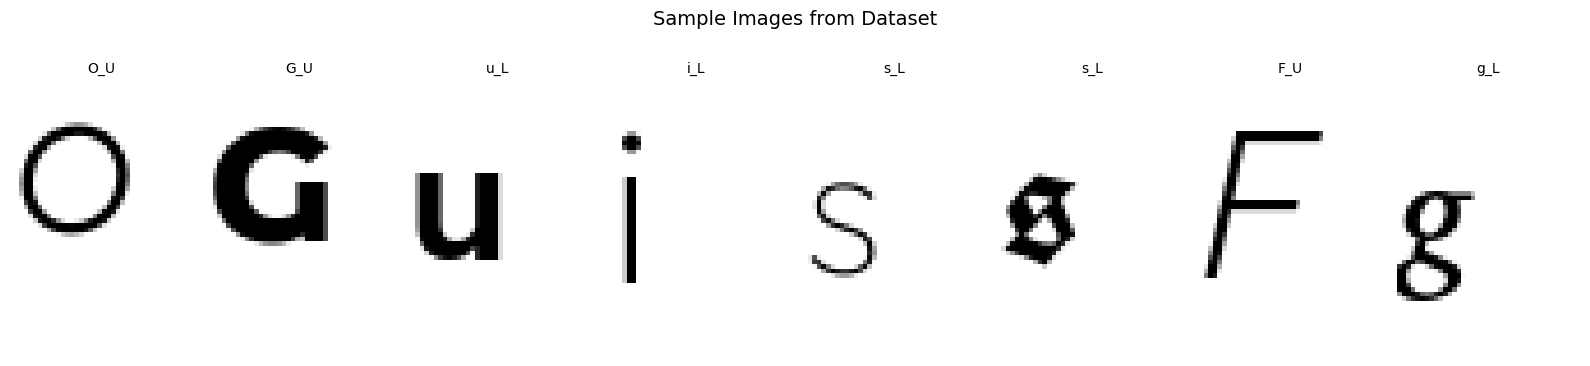


Batch shape: torch.Size([32, 1, 60, 40])
Labels shape: torch.Size([32])
Sample labels: tensor([41, 28, 15,  2, 18, 52, 17, 58, 52, 43])
Corresponding classes: ['f_L', 'S_U', 'F_U', '2', 'I_U', 'q_L', 'H_U', 'w_L', 'q_L', 'h_L']


In [ ]:
# Function to show images
def show_images(loader, class_names, num_images=8):
    # Get a batch of images
    data_iter = iter(loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(16, 4))
    for i in range(num_images):
        # Convert tensor to numpy for display
        img = images[i].squeeze().numpy()  # Remove channel dimension
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'{class_names[labels[i]]}', fontsize=10)
        axes[i].axis('off')
    plt.suptitle('Sample Images from Dataset', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show sample images
show_images(train_loader, class_names)

# Check batch shape
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"\nBatch shape: {images.shape}")  # [batch_size, 1, 60, 40]
print(f"Labels shape: {labels.shape}")
print(f"Sample labels: {labels[:10]}")
print(f"Corresponding classes: {[class_names[l] for l in labels[:10]]}")

# Define the CNN Model

In [ ]:
class OCRCNN(nn.Module):
    def __init__(self, num_classes=62):
        super(OCRCNN, self).__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.AvgPool2d(kernel_size=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.pool2 = nn.AvgPool2d(kernel_size=2)

        # Third convolutional block
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)
        self.pool3 = nn.AvgPool2d(kernel_size=2)

        # Calculate the size after convolutions and pooling
        # Input: 60x40
        # After conv1+pool1: 30x20
        # After conv2+pool2: 14x9 (30-2=28, /2=14; 20-2=18, /2=9)
        # After conv3+pool3: 6x3 (14-2=12, /2=6; 9-2=7, /2=3)
        self.flatten_size = 32 * 6 * 3  # 32 channels * 6 * 3 = 576

        # Fully connected layer
        self.fc = nn.Linear(self.flatten_size, num_classes)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # First block
        x = self.relu(self.conv1(x))
        x = self.pool1(x)

        # Second block
        x = self.relu(self.conv2(x))
        x = self.pool2(x)

        # Third block
        x = self.relu(self.conv3(x))
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)  # Flatten all dimensions except batch

        # Fully connected
        x = self.fc(x)

        return x

In [ ]:
# Create model instance
model = OCRCNN(num_classes=62).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

OCRCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc): Linear(in_features=576, out_features=62, bias=True)
  (relu): ReLU()
)

Total parameters: 54,590
Trainable parameters: 54,590


# Training

In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Early stopping parameters
early_stop_patience = 5
best_val_accuracy = 0
best_val_loss = float('inf')
epochs_no_improve = 0

# Lists to store metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Create directory for saving models
os.makedirs('./models', exist_ok=True)
os.makedirs('./models/checkpoints', exist_ok=True)

# Training Functions

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Training Loop

In [ ]:
num_epochs = 10

print("Starting training...")
print("=" * 60)

for epoch in range(1, num_epochs + 1):
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save checkpoint every epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
    }, f'./models/checkpoints/epoch_{epoch:02d}.pth')

    # Check for best model (based on validation accuracy)
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save best model
        torch.save(model.state_dict(), './models/best_ocr_model.pth')
        print(f"Epoch {epoch}: New best model saved! Val Acc: {val_acc:.4f} (improved)")
    else:
        epochs_no_improve += 1
        print(f"Epoch {epoch}: Val Acc: {val_acc:.4f} (no improvement for {epochs_no_improve} epochs)")

    # Print epoch results
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print("-" * 60)

    # Early stopping
    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping triggered after {epoch} epochs")
        break

print("\nTraining complete!")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...
Epoch 1: New best model saved! Val Acc: 0.8373 (improved)
  Train Loss: 1.0676, Train Acc: 0.7491
  Val Loss: 0.6637, Val Acc: 0.8373
------------------------------------------------------------
Epoch 2: New best model saved! Val Acc: 0.8620 (improved)
  Train Loss: 0.6050, Train Acc: 0.8486
  Val Loss: 0.5687, Val Acc: 0.8620
------------------------------------------------------------
Epoch 3: New best model saved! Val Acc: 0.8715 (improved)
  Train Loss: 0.5138, Train Acc: 0.8668
  Val Loss: 0.4984, Val Acc: 0.8715
------------------------------------------------------------
Epoch 4: New best model saved! Val Acc: 0.8793 (improved)
  Train Loss: 0.4616, Train Acc: 0.8790
  Val Loss: 0.4625, Val Acc: 0.8793
------------------------------------------------------------
Epoch 5: New best model saved! Val Acc: 0.8822 (improved)
  Train Loss: 0.4253, Train Acc: 0.8860
  Val Loss: 0.4478, Val Acc: 0.8822
------------------------------------------------------------
Epoc

# Plot Training History

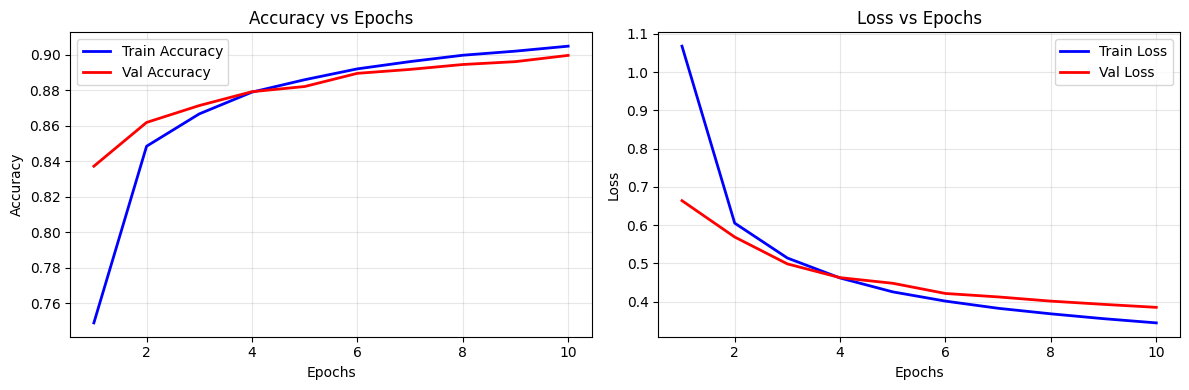

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'b-', label='Train Accuracy', linewidth=2)
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'r-', label='Val Accuracy', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-', label='Val Loss', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./models/training_history.png', dpi=150)
plt.show()

# Evaluate on Test Set

Best model loaded for testing!

Test Results:
Test Loss: 0.3747
Test Accuracy: 0.9002


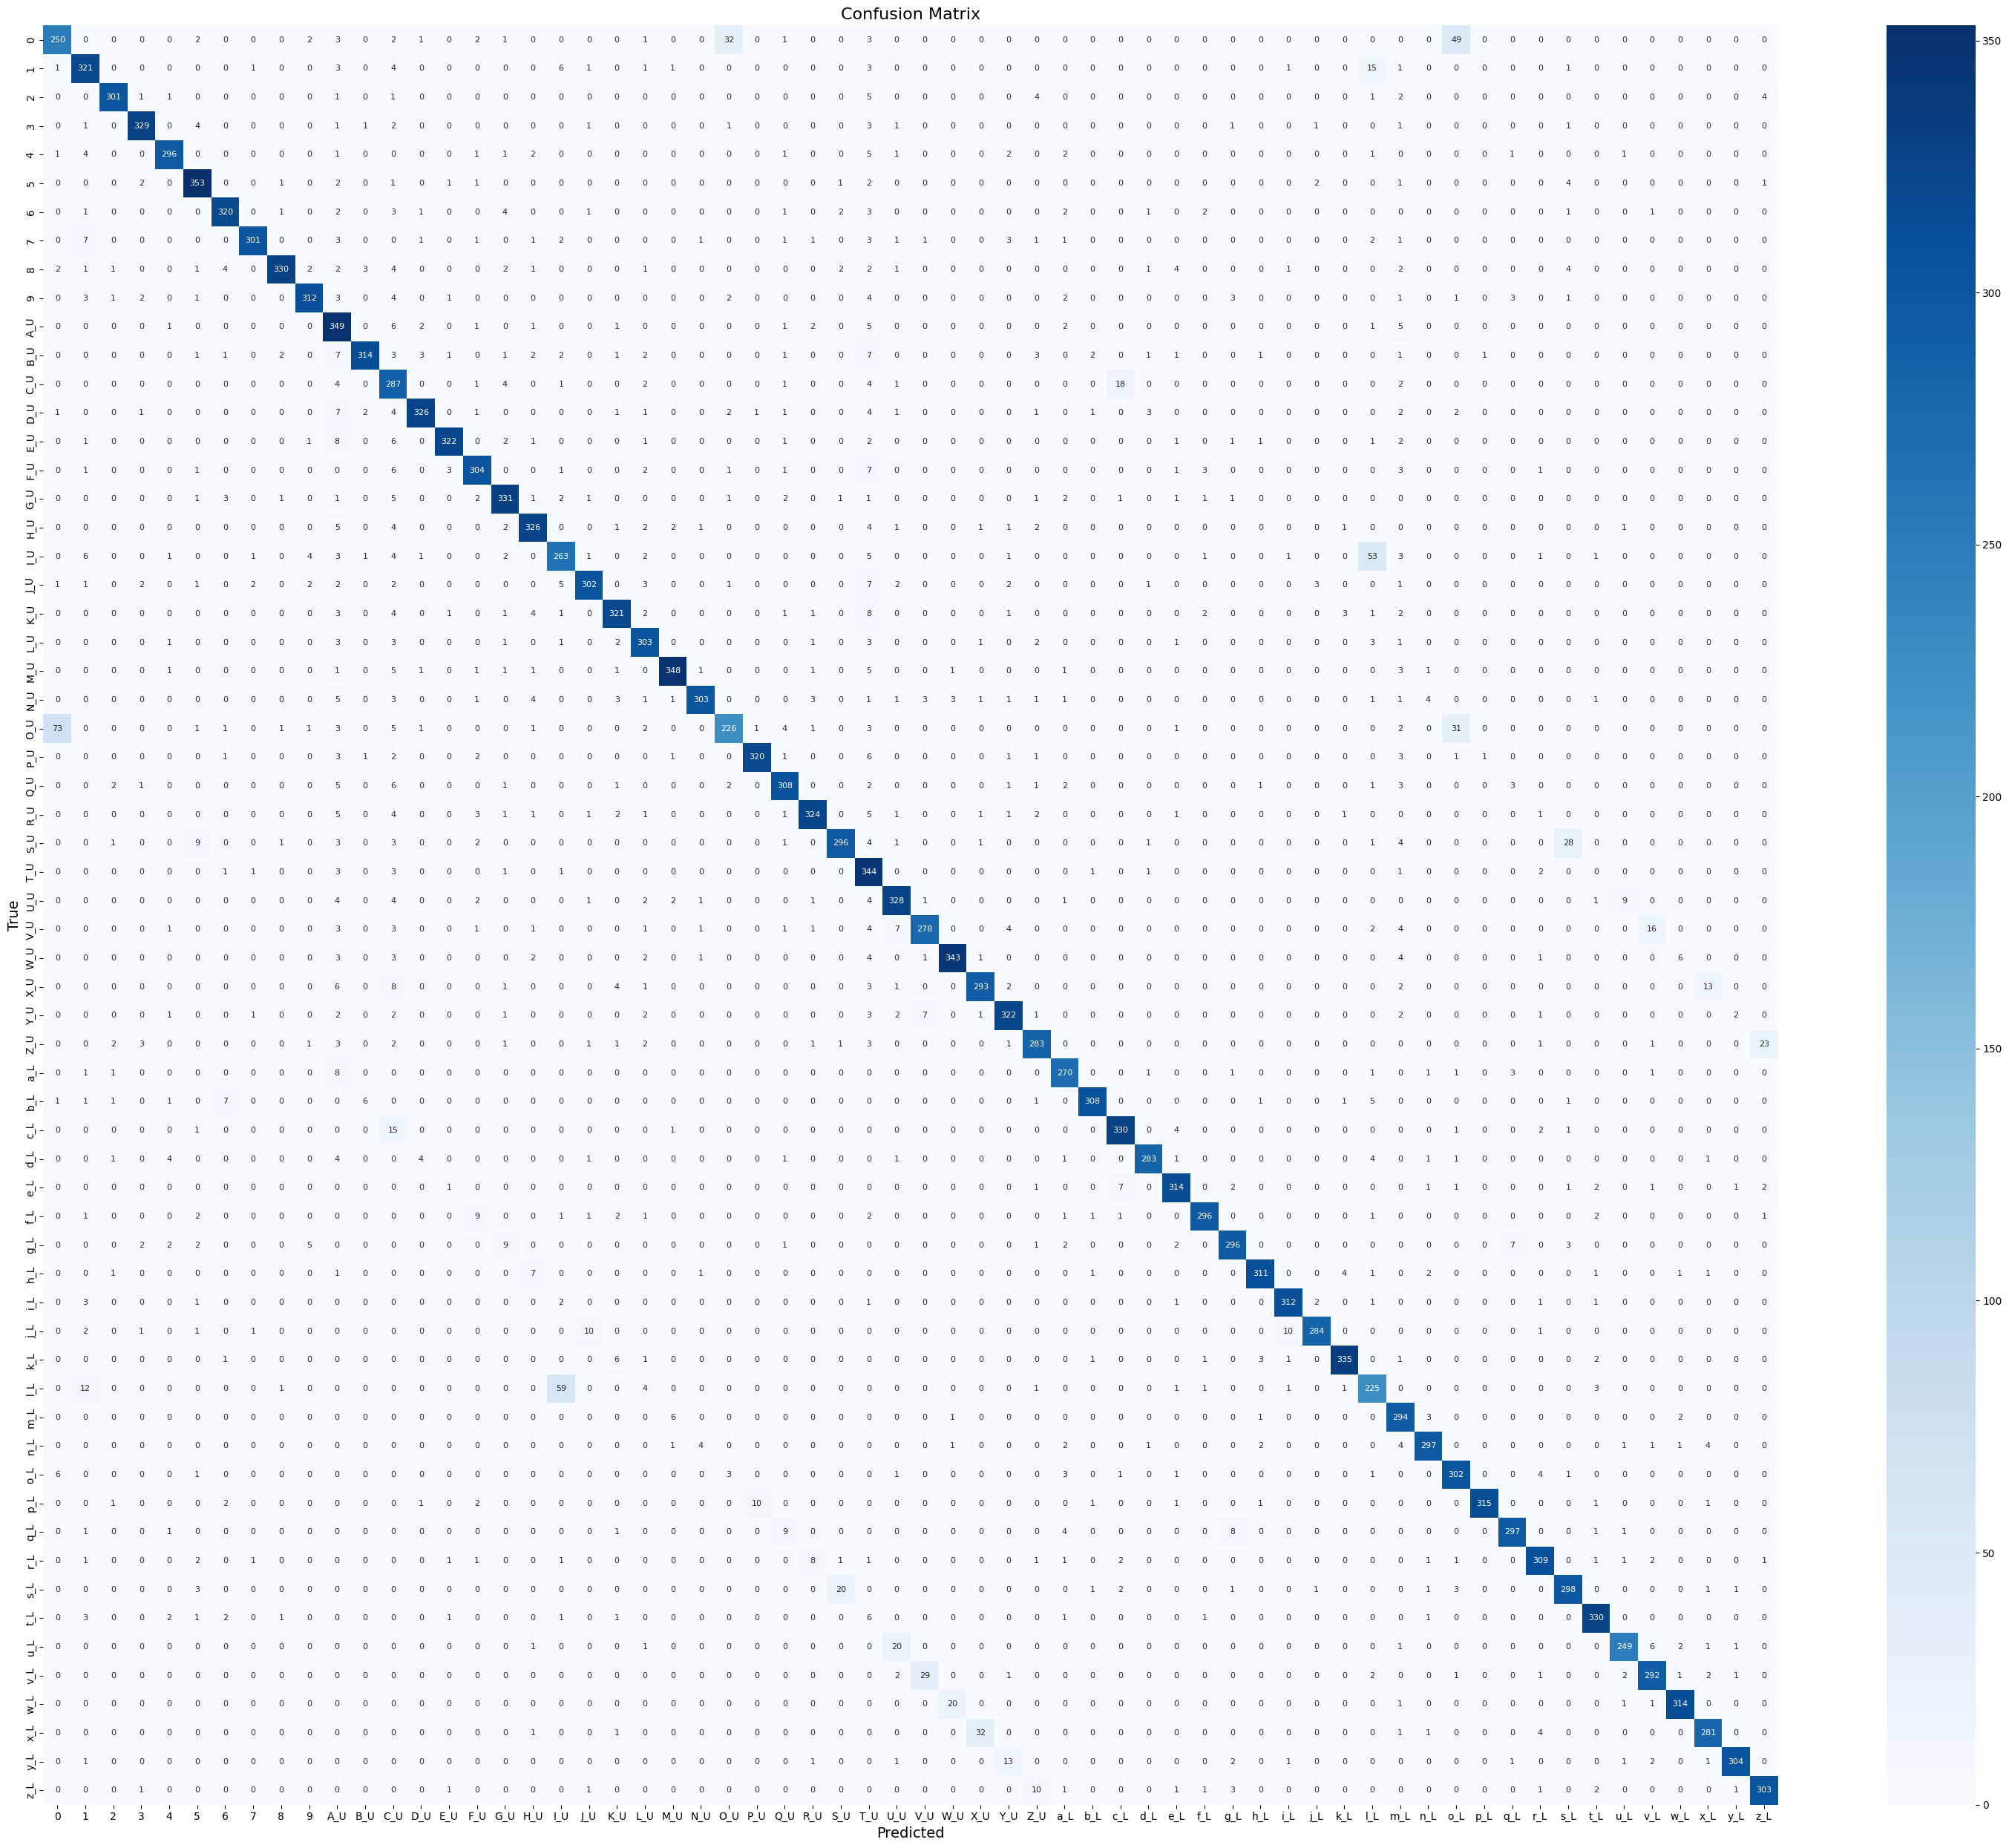


Top 10 Best Performing Classes:
  i_L: 0.9600
  T_U: 0.9582
  m_L: 0.9577
  k_L: 0.9517
  5: 0.9489
  3: 0.9454
  t_L: 0.9402
  e_L: 0.9401
  2: 0.9377
  p_L: 0.9375

Top 10 Worst Performing Classes:
  B_U: 0.8771
  x_L: 0.8754
  v_L: 0.8743
  Z_U: 0.8576
  V_U: 0.8476
  S_U: 0.8315
  I_U: 0.7408
  l_L: 0.7282
  0: 0.7163
  O_U: 0.6313


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load best model
model.load_state_dict(torch.load('./models/best_ocr_model.pth'))
print("Best model loaded for testing!")

# Evaluate on test set
test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions for confusion matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

predictions, true_labels = get_predictions(model, test_loader, device)

# Create confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot confusion matrix (might be large, so we'll make it scrollable)
plt.figure(figsize=(30, 25))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 8})
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('./models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate per-class accuracy
class_accuracy = {}
for i, class_name in enumerate(class_names):
    mask = true_labels == i
    if np.sum(mask) > 0:
        class_acc = np.sum(predictions[mask] == i) / np.sum(mask)
        class_accuracy[class_name] = class_acc

# Print top 10 best and worst performing classes
sorted_classes = sorted(class_accuracy.items(), key=lambda x: x[1], reverse=True)
print("\nTop 10 Best Performing Classes:")
for class_name, acc in sorted_classes[:10]:
    print(f"  {class_name}: {acc:.4f}")

print("\nTop 10 Worst Performing Classes:")
for class_name, acc in sorted_classes[-10:]:
    print(f"  {class_name}: {acc:.4f}")

# Random Testing Function


Testing on random samples...


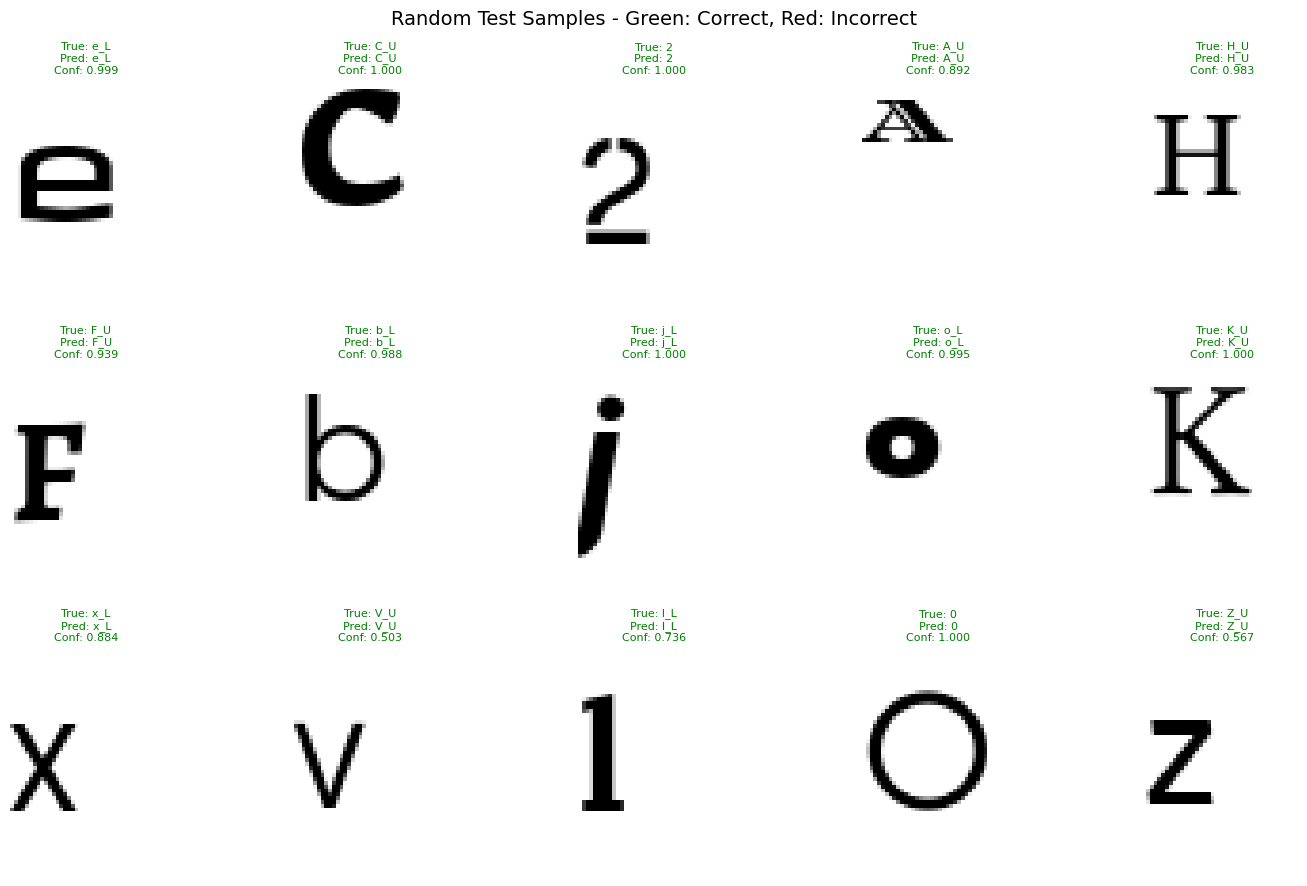


Random sample accuracy: 1.0000 (15/15)


In [ ]:
import random
def load_random_sample(data_path, class_names, num_samples=10):
    """Load random samples from each class"""
    images = []
    true_labels = []
    image_paths = []

    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_path, class_name)
        if not os.path.exists(class_path):
            continue

        # Get all image files
        img_files = [f for f in os.listdir(class_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if img_files:
            # Pick a random image
            random_img = random.choice(img_files)
            img_path = os.path.join(class_path, random_img)
            image_paths.append((class_name, img_path))

    # Randomly select num_samples from the list
    selected = random.sample(image_paths, min(num_samples, len(image_paths)))

    for class_name, img_path in selected:
        # Load and preprocess image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (40, 60))  # Resize to 60x40 (height, width)
            images.append(img)
            true_labels.append(class_names.index(class_name))

    return images, true_labels

def predict_images(model, images, device):
    """Predict class for a list of images"""
    model.eval()
    predictions = []
    probabilities = []

    transform_test = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Grayscale(),
        transforms.Resize((60, 40)),
        transforms.ToTensor(),
    ])

    with torch.no_grad():
        for img in images:
            img_tensor = transform_test(img).unsqueeze(0).to(device)
            output = model(img_tensor)
            probs = torch.softmax(output, dim=1)
            _, predicted = torch.max(output, 1)

            predictions.append(predicted.item())
            probabilities.append(probs[0][predicted].item())

    return predictions, probabilities

def plot_random_results(images, true_labels, predictions, probabilities, class_names):
    """Plot random test images with predictions"""
    num_images = len(images)
    cols = 5
    rows = (num_images + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()

    for i in range(num_images):
        axes[i].imshow(images[i], cmap='gray')

        # Color code based on correctness
        is_correct = predictions[i] == true_labels[i]
        color = 'green' if is_correct else 'red'

        title = f"True: {class_names[true_labels[i]]}\n"
        title += f"Pred: {class_names[predictions[i]]}\n"
        title += f"Conf: {probabilities[i]:.3f}"

        axes[i].set_title(title, fontsize=8, color=color)
        axes[i].axis('off')

    # Hide empty subplots
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Random Test Samples - Green: Correct, Red: Incorrect', fontsize=14)
    plt.tight_layout()
    plt.show()

# Test on random samples
print("\nTesting on random samples...")
random_images, true_labels = load_random_sample(data_path, class_names, num_samples=15)
predictions, probabilities = predict_images(model, random_images, device)

# Plot results
plot_random_results(random_images, true_labels, predictions, probabilities, class_names)

# Calculate accuracy on random sample
random_acc = np.mean(np.array(predictions) == np.array(true_labels))
print(f"\nRandom sample accuracy: {random_acc:.4f} ({np.sum(np.array(predictions) == np.array(true_labels))}/{len(true_labels)})")